# 📊 Netflix Data Visualization Project

## 📌 Objective
To create meaningful and visually appealing charts that communicate key insights from the Netflix dataset.

## 📌 Business Understanding

The objective of this project is to create meaningful visualizations from the Netflix dataset to understand content distribution, growth trends, and audience targeting.  
The focus is on transforming raw data into visual insights that clearly communicate patterns and support decision-making.

## ❓ Key Business Questions

- How is Netflix content distributed between Movies and TV Shows?
- How has Netflix content grown over time?
- What type of audience does Netflix primarily target?
- What patterns exist in content ratings and distribution?
- Are there any data quality issues that impact analysis?

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.style.use('ggplot')

In [8]:
df = pd.read_csv("C:/Users/Bhavana/OneDrive/Desktop/1/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [10]:
df.fillna({
    'country': 'Unknown',
    'director': 'Unknown',
    'cast': 'Unknown',
    'rating': 'Unknown'
}, inplace=True)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


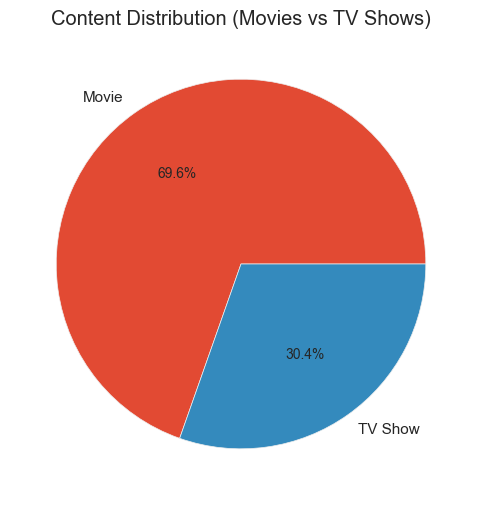

In [13]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%')
plt.title("Content Distribution (Movies vs TV Shows)")
plt.show()

The platform is heavily dominated by movies, indicating that Netflix prioritizes film-based content over episodic storytelling.

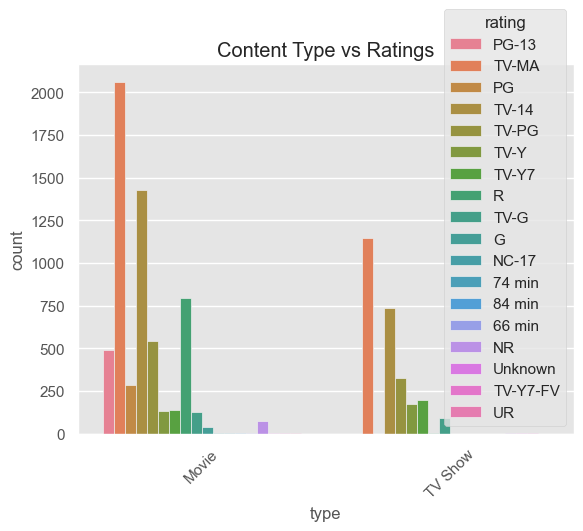

In [19]:
sns.countplot(data=df, x='type', hue='rating')
plt.title("Content Type vs Ratings")
plt.xticks(rotation=45)
plt.show()

Movies dominate across most rating categories, but TV Shows show stronger presence in specific audience segments.

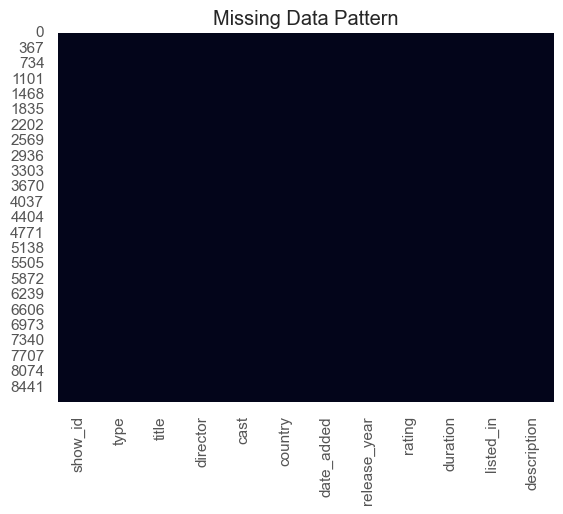

In [20]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

The heatmap reveals structured missingness in key columns like country, director, and cast.  
This pattern suggests that the dataset lacks complete metadata for several titles, which can affect the reliability of insights related to content production and contributors.

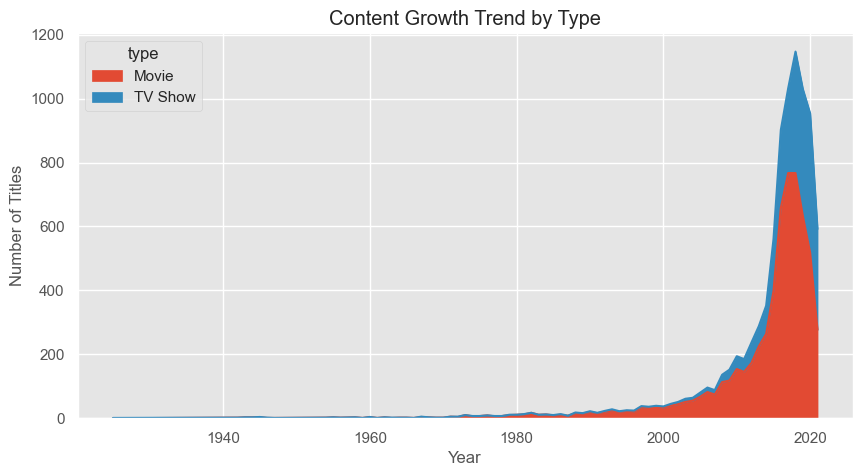

In [16]:
type_year = df.groupby(['release_year','type']).size().unstack()

type_year.plot(kind='area', figsize=(10,5))
plt.title("Content Growth Trend by Type")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

Netflix shows rapid expansion after 2015, with both movies and TV shows increasing. However, movies continue to dominate, while TV shows show gradual growth.

## 🧪 Hypothesis Testing

Hypothesis 1: Netflix content has significantly increased after 2015.  
✔️ Supported by visualization showing rapid growth in recent years.

Hypothesis 2: Movies dominate Netflix content.  
✔️ Confirmed by distribution visualizations.

Hypothesis 3: Netflix primarily targets mature audiences.  
✔️ Supported by higher frequency of TV-MA and TV-14 ratings.

In [ ]:
## ⚠️ Data Issues

- Missing values are present in columns such as country, director, and cast  
- Incomplete metadata may affect deeper analysis  
- Imbalance between Movies and TV Shows  
- Some entries contain multiple countries, requiring data transformation for accurate insights  

## 📖 Visual Story

The visualizations reveal that Netflix has experienced rapid growth in content production, especially after 2015.  
Movies dominate the platform, while TV Shows are steadily increasing, indicating gradual diversification.  

The rating distribution shows a strong focus on mature audiences, suggesting targeted content strategies.  
Additionally, the dataset highlights gaps in metadata, which may influence detailed analysis.

Overall, the data reflects Netflix’s expansion into a globally dominant streaming platform.

## 🏁 Conclusion

This visualization project effectively communicates key trends and insights from the Netflix dataset.  
Through clear and structured visuals, it highlights content growth, distribution patterns, and audience focus.  

The findings demonstrate Netflix’s strong expansion strategy and its emphasis on delivering content tailored to mature audiences.